In [1]:
from module import *

In [2]:
modelpar={
    "M":9.38,
    "m_sigma":4.0,
    "g2":-21.191683999999999,
    "g3":-4.04529,
    "g_sigma":6.3935,
    "m_omega":7.83,
    "g_omega":8.7207,
    "g_rho":4.2696,
    "m_rho":7.690,
    "electronmass":0.00511,
    "echarge":0.303
}
print(modelpar)

{'M': 9.38, 'm_sigma': 4.0, 'g2': -21.191684, 'g3': -4.04529, 'g_sigma': 6.3935, 'm_omega': 7.83, 'g_omega': 8.7207, 'g_rho': 4.2696, 'm_rho': 7.69, 'electronmass': 0.00511, 'echarge': 0.303}


In [1]:
device='cuda:0' if torch.cuda.is_available() else 'cpu'  # auto: GPU on Linux, CPU on Mac
rho_p=(torch.ones(20)*0.1*1.97*1.97*1.97).to(torch.device(device))
rho_n=(torch.ones(20)*0.1*1.97*1.97*1.97).to(torch.device(device))
grid_corer=2
rhonum=50
rho=torch.linspace(0,0.32,rhonum)
epsres=torch.zeros(rhonum)
netwdf=rmftorch(modelpar,rho_p,rho_n,bn_n=0,bn_p=0,grid_corer=grid_corer,grid_maxr=1000,device=device).to(torch.device(device))
core_V=(grid_corer**3*4*np.pi/3)

for i in range(rhonum):
    rho_nn=rho[i]
    rho_pp=rho[i]
    bn_n=rho_nn*core_V
    bn_p=rho_pp*core_V
    netwdf.bn_n=bn_n
    netwdf.bn_p=bn_p
    print(str(rho_pp.detach().numpy())+":"+str(netwdf.rho_p()[0]/1.97**3))
    epsres[i]=netwdf.eps()[10]/1.97/1.97/1.97*100

print(epsres)
plt.plot(rho.detach().numpy()*2,epsres.detach().numpy()/(rho.detach().numpy()*2)-938)
# protonchargemiddle: tensor([0.7645, 0.7645, 0.7645, 0.7645, 0.7645, 0.7645, 0.7645, 0.7645, 0.7645,
#         0.7645, 0.7645, 0.7645, 0.7645, 0.7645, 0.7645, 0.7645, 0.7645, 0.7645,
#         0.3823], device='cuda:2', grad_fn=<SliceBackward0>)
# self.raduisdiff_v3[:self.pn_grid_num-1]: tensor([0.0002, 0.0011, 0.0029, 0.0057, 0.0094, 0.0139, 0.0194, 0.0258, 0.0332,
#         0.0414, 0.0505, 0.0606, 0.0716, 0.0834, 0.0962, 0.1099, 0.1246, 0.1401,
#         0.1565], device='cuda:2')
# self.raduisdiff_v3[:self.pn_grid_num-1]*torch.pi*4/3*protonchargemiddle: tensor([0.0005, 0.0035, 0.0094, 0.0182, 0.0300, 0.0446, 0.0622, 0.0827, 0.1062,
#         0.1325, 0.1618, 0.1940, 0.2291, 0.2672, 0.3082, 0.3521, 0.3989, 0.4486,
#         0.2506], device='cuda:2', grad_fn=<MulBackward0>)

NameError: name 'torch' is not defined

/tmp/ipykernel_558987/2225845643.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(rho.detach().numpy()*2,epsres.detach().numpy()/(rho.detach().numpy()*2)-938)


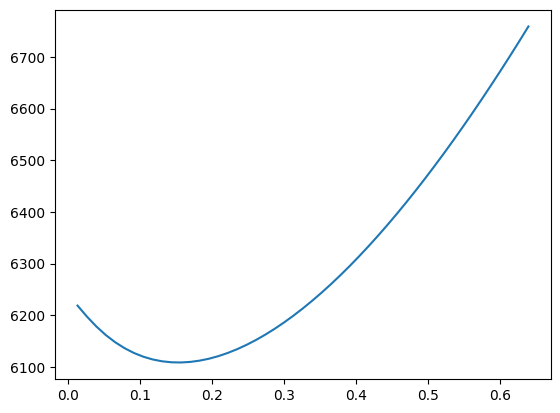

In [3]:
12/(4*np.pi/3*1.9**3)

0.41766860703515335

In [39]:
print(rho.detach().numpy()*2,epsres.detach().numpy()/(rho.detach().numpy()*2)-938)

[0.         0.01306122 0.02612245 0.03918367 0.0522449  0.06530612
 0.07836735 0.09142857 0.1044898  0.11755102 0.13061224 0.14367346
 0.15673469 0.16979592 0.18285714 0.19591837 0.20897959 0.22204082
 0.23510204 0.24816327 0.26122448 0.2742857  0.28734693 0.30040815
 0.31346938 0.3265306  0.33959183 0.35265306 0.36571428 0.3787755
 0.39183673 0.40489796 0.41795918 0.43102038 0.4440816  0.45714283
 0.47020406 0.48326528 0.4963265  0.50938773 0.52244896 0.5355102
 0.5485714  0.56163263 0.57469386 0.5877551  0.6008163  0.61387753
 0.62693876 0.64      ] [        nan  -1.8946533  -4.6712036  -7.1724854  -9.332336  -11.155212
 -12.663452  -13.880066  -14.828552  -15.526855  -15.9939575 -16.24469
 -16.293152  -16.150269  -15.828369  -15.336914  -14.682861  -13.875244
 -12.920532  -11.825073  -10.593994   -9.2335205  -7.7476807  -6.140747
  -4.416809   -2.579895   -0.6333618   1.4199219   3.5769653   5.8342285
   8.189331   10.640564   13.184387   15.818848   18.54242    21.352173
  24.24658

/tmp/ipykernel_1540739/4145775378.py:1: RuntimeWarning: invalid value encountered in divide
  print(rho.detach().numpy()*2,epsres.detach().numpy()/(rho.detach().numpy()*2)-938)


In [40]:
netwdf.echarge


tensor(0.3030)